# 🔍 Exploratory Data Analysis — Churn Modelling

Ce notebook présente une EDA complète sur le dataset **Churn Modelling** (~10 000 clients bancaires).  
L'objectif est de comprendre les données, détecter les patterns liés au churn (`Exited = 1`), et préparer le terrain pour la modélisation.

---
**Plan :**
1. Chargement & aperçu
2. Qualité des données (valeurs manquantes, doublons, types)
3. Distribution de la variable cible
4. Statistiques descriptives
5. Variables numériques : distributions & outliers
6. Variables catégorielles
7. Analyse bivariée : churn vs features
8. Matrice de corrélation
9. Analyses croisées avancées
10. Synthèse & conclusions

## 0. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from src.mlops_tp.config import DATA_FILE
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
PALETTE = {'Retained': '#2ecc71', 'Churned': '#e74c3c'}
COLOR_CHURN = '#e74c3c'
COLOR_RETAIN = '#2ecc71'
sns.set_style('whitegrid')

print('✅ Imports OK')

✅ Imports OK


## 1. Chargement & Aperçu des données

In [3]:
df = pd.read_csv(DATA_FILE)

# Supprimer les colonnes non-informatives
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print(f'Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Après nettoyage : {df_clean.shape[0]:,} lignes × {df_clean.shape[1]} colonnes')
df.head()

Dimensions : 10,000 lignes × 14 colonnes
Après nettoyage : 10,000 lignes × 11 colonnes


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print('=== Types de données ===')
print(df_clean.dtypes)
print(f'\n=== Variables numériques ===')
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('Exited')  # target
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
bin_cols = ['HasCrCard', 'IsActiveMember']
cont_cols = [c for c in num_cols if c not in bin_cols]
print('  Continues :', cont_cols)
print('  Binaires  :', bin_cols)
print('  Catégorielles :', cat_cols)

=== Types de données ===
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

=== Variables numériques ===
  Continues : ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
  Binaires  : ['HasCrCard', 'IsActiveMember']
  Catégorielles : ['Geography', 'Gender']


## 2. Qualité des données

In [5]:
print('=== Valeurs manquantes ===')
missing = df_clean.isnull().sum()
print(missing[missing > 0] if missing.any() else '✅ Aucune valeur manquante !')

print(f'\n=== Doublons ===')
dupes = df.duplicated().sum()
print(f'✅ {dupes} doublon(s) trouvé(s)' if dupes == 0 else f'⚠️ {dupes} doublons !')

print(f'\n=== Cohérence des valeurs ===')
print('Geography :', df['Geography'].unique())
print('Gender    :', df['Gender'].unique())
print('NumOfProducts :', sorted(df['NumOfProducts'].unique()))
print('HasCrCard :', df['HasCrCard'].unique())
print('IsActiveMember :', df['IsActiveMember'].unique())
print('Exited :', df['Exited'].unique())

=== Valeurs manquantes ===
✅ Aucune valeur manquante !

=== Doublons ===
✅ 0 doublon(s) trouvé(s)

=== Cohérence des valeurs ===
Geography : ['France' 'Spain' 'Germany']
Gender    : ['Female' 'Male']
NumOfProducts : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
HasCrCard : [1 0]
IsActiveMember : [1 0]
Exited : [1 0]


## 3. Distribution de la variable cible — Churn

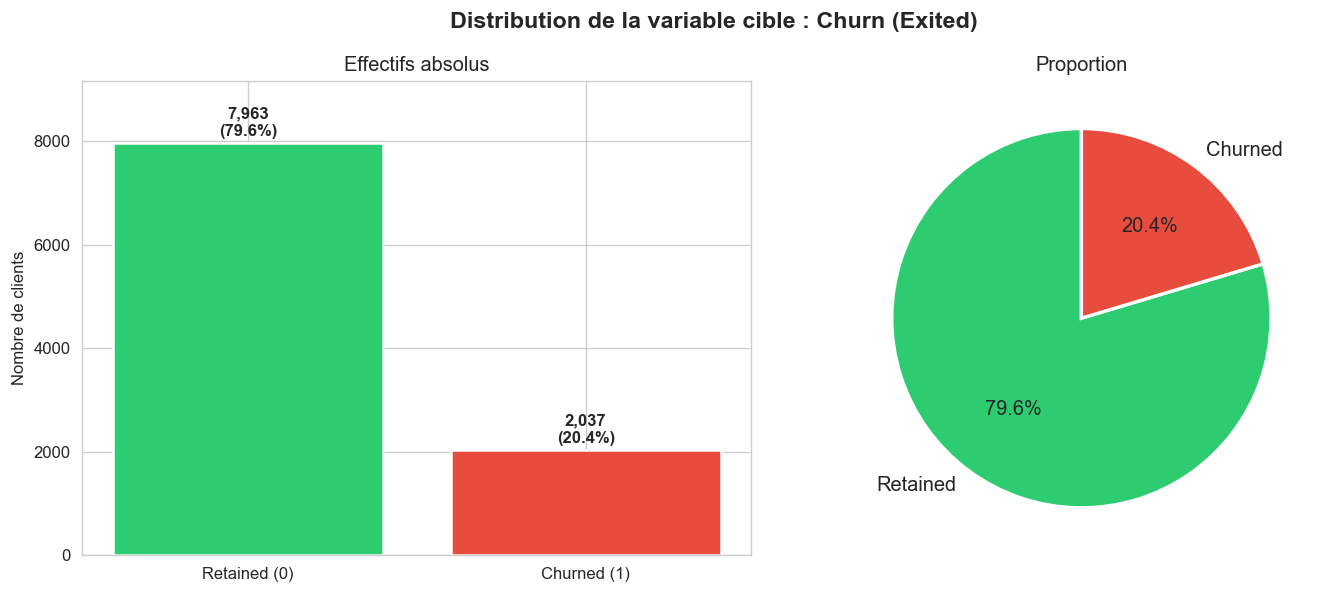


📊 Taux de churn : 20.37%
   → Dataset déséquilibré (79.6% vs 20.4%)


In [6]:
churn_counts = df_clean['Exited'].value_counts()
churn_pct = df_clean['Exited'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribution de la variable cible : Churn (Exited)', fontsize=14, fontweight='bold')

# Barplot
bars = axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values,
                   color=[COLOR_RETAIN, COLOR_CHURN], edgecolor='white', linewidth=1.5)
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Effectifs absolus')
axes[0].set_ylabel('Nombre de clients')
axes[0].set_ylim(0, churn_counts.max() * 1.15)

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'],
            colors=[COLOR_RETAIN, COLOR_CHURN],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title('Proportion')

plt.tight_layout()
plt.show()

print(f'\n📊 Taux de churn : {churn_pct[1]:.2f}%')
print(f'   → Dataset déséquilibré ({churn_pct[0]:.1f}% vs {churn_pct[1]:.1f}%)')

## 4. Statistiques descriptives

In [7]:
print('=== Statistiques descriptives — Variables continues ===')
df_clean[cont_cols + ['Exited']].describe().round(2)

=== Statistiques descriptives — Variables continues ===


,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,650.53,38.92,5.01,76485.89,1.53,100090.24,0.2
std,96.65,10.49,2.89,62397.41,0.58,57510.49,0.4
min,350.00,18.00,0.00,0.00,1.00,11.58,0.0
25%,584.00,32.00,3.00,0.00,1.00,51002.11,0.0
50%,652.00,37.00,5.00,97198.54,1.00,100193.92,0.0
75%,718.00,44.00,7.00,127644.24,2.00,149388.25,0.0
max,850.00,92.00,10.00,250898.09,4.00,199992.48,1.0


In [8]:
print('=== Statistiques par groupe (Retained vs Churned) ===')
df_clean.groupby('Exited')[cont_cols].agg(['mean','median','std']).round(2)

=== Statistiques par groupe (Retained vs Churned) ===


CreditScore                   Age               Tenure               \
              mean median     std   mean median    std   mean median   std   
Exited                                                                       
0           651.85  653.0   95.65  37.41   36.0  10.13   5.03    5.0  2.88   
1           645.35  646.0  100.32  44.84   45.0   9.76   4.93    5.0  2.94   

         Balance                      NumOfProducts               \
            mean     median       std          mean median   std   
Exited                                                             
0       72745.30   92072.68  62848.04          1.54    2.0  0.51   
1       91108.54  109349.29  58360.79          1.48    1.0  0.80   

       EstimatedSalary                       
                  mean     median       std  
Exited                                       
0             99738.39   99645.04  57405.59  
1            101465.68  102460.84  57912.42

## 5. Variables numériques — Distributions & Outliers

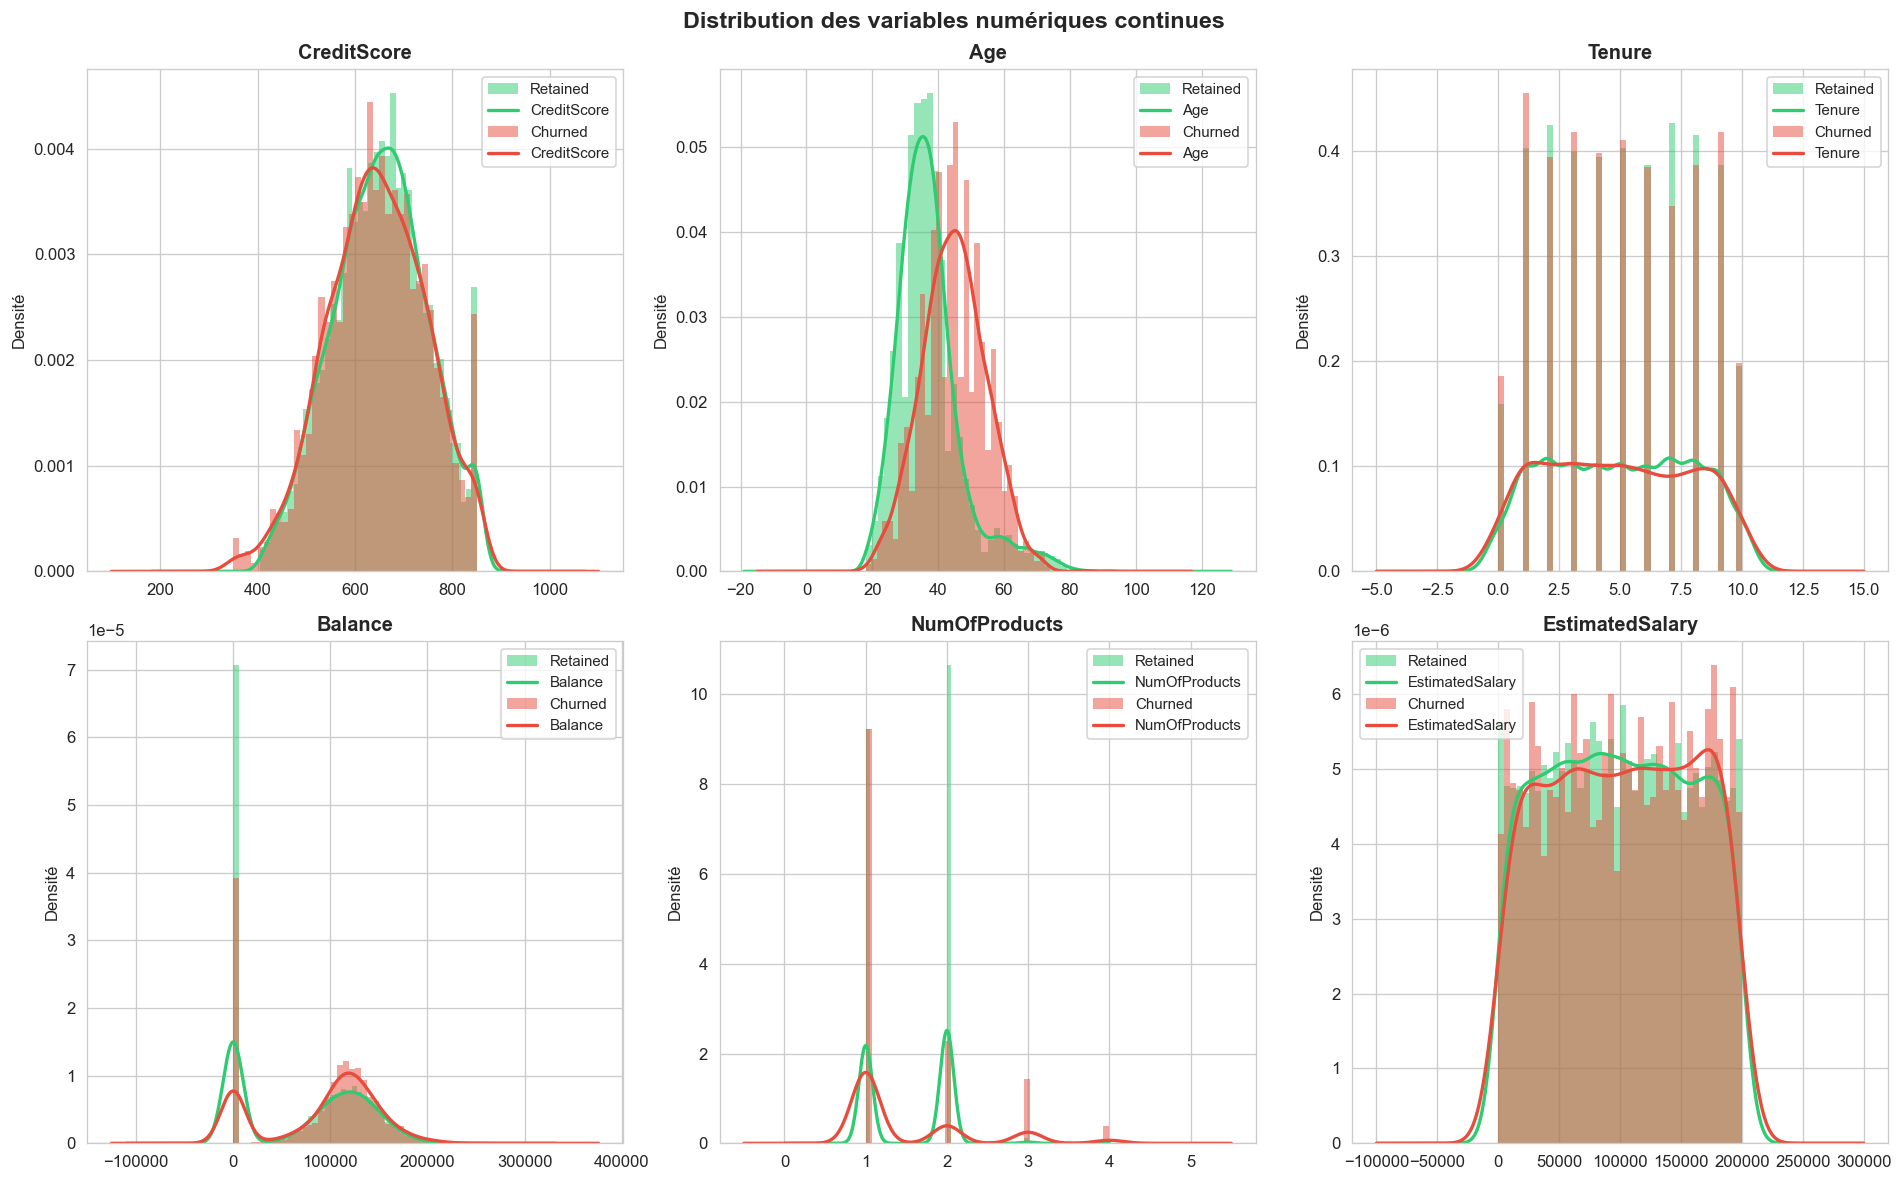

In [9]:
# Histogrammes + KDE pour chaque variable continue
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution des variables numériques continues', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    ax = axes[i]
    for exited, label, color in [(0, 'Retained', COLOR_RETAIN), (1, 'Churned', COLOR_CHURN)]:
        data = df_clean[df_clean['Exited'] == exited][col]
        ax.hist(data, bins=40, alpha=0.5, color=color, label=label, density=True, edgecolor='none')
        data.plot.kde(ax=ax, color=color, linewidth=2)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=9)
    ax.set_ylabel('Densité')

# Désactiver les axes vides
for j in range(len(cont_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

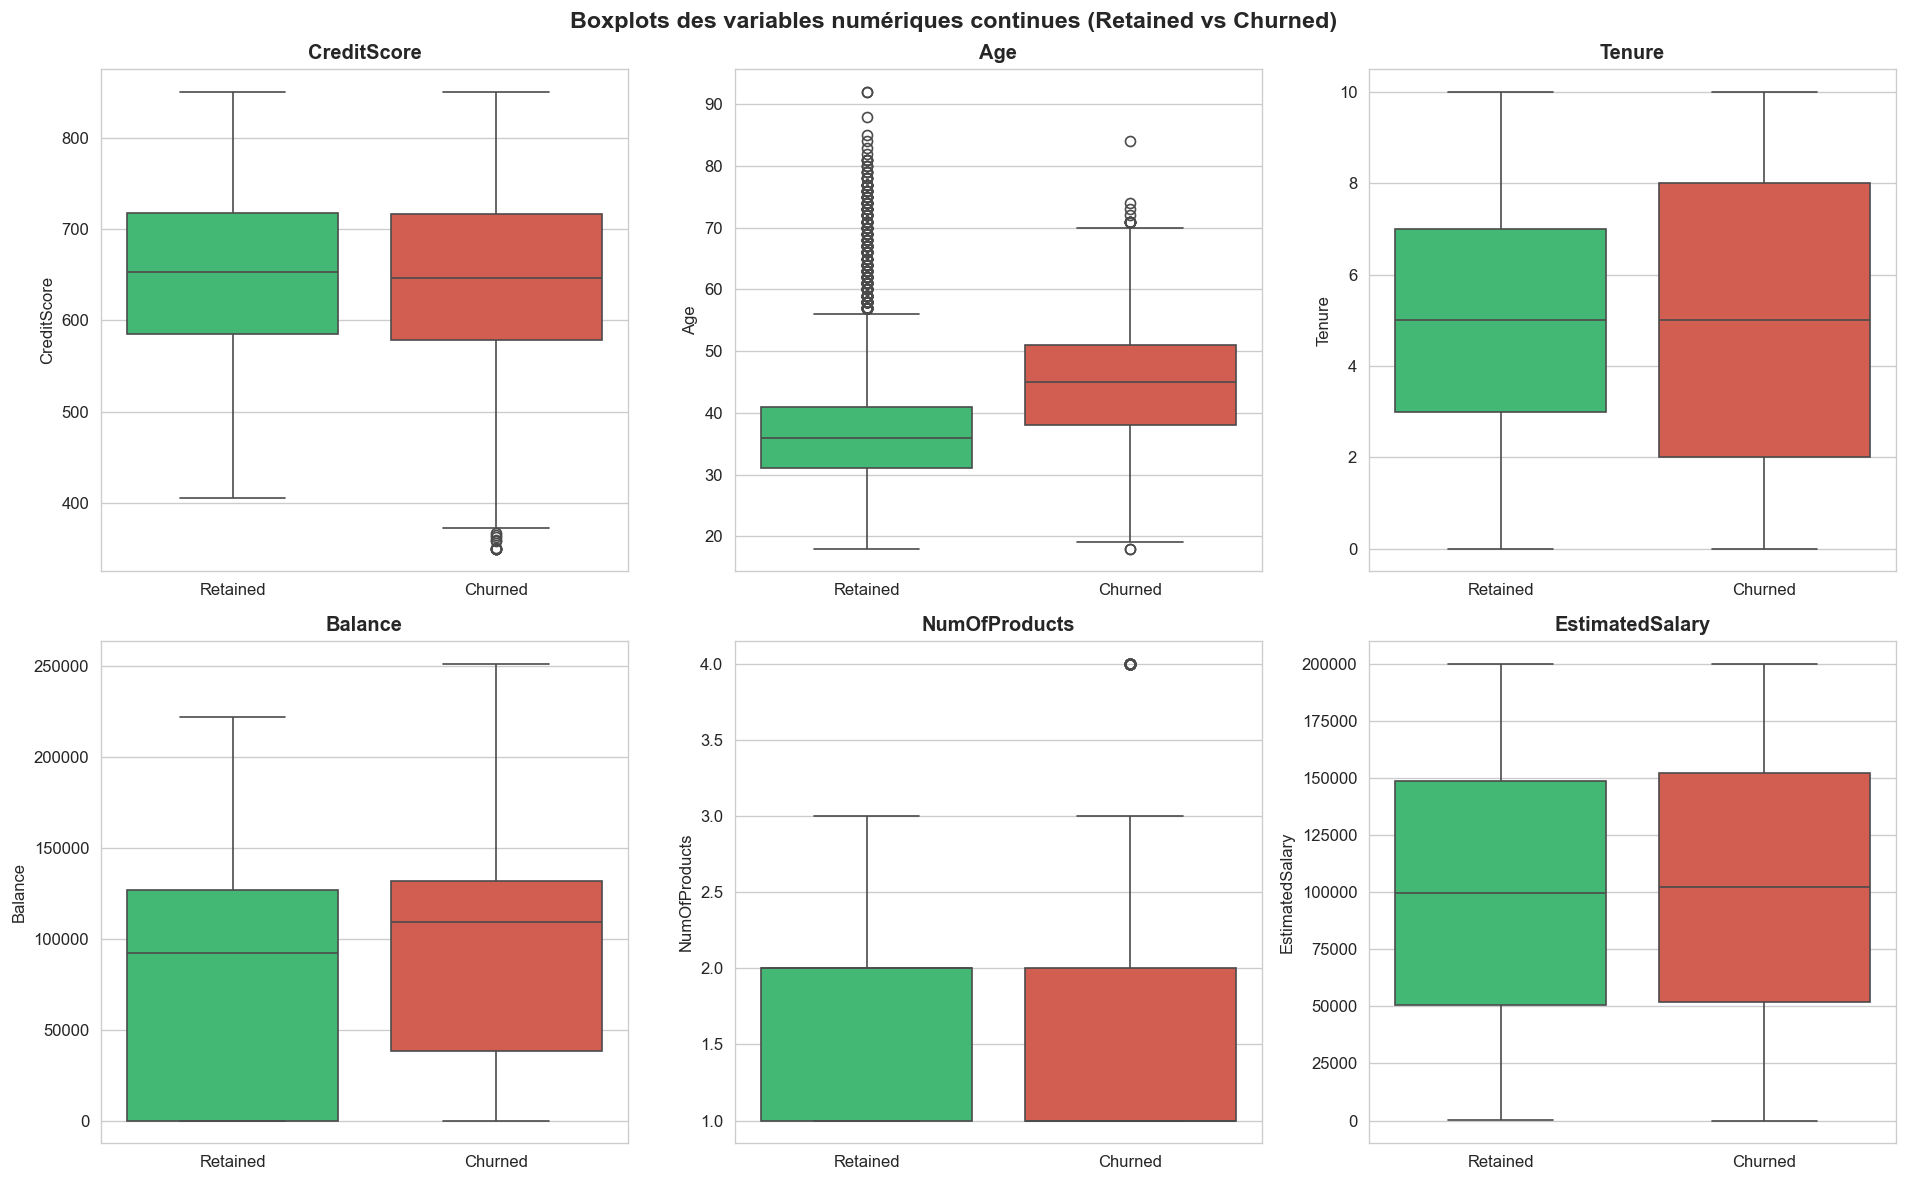

In [10]:
# Boxplots pour détecter les outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Boxplots des variables numériques continues (Retained vs Churned)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    ax = axes[i]
    data_plot = df_clean[[col, 'Exited']].copy()
    data_plot['Status'] = data_plot['Exited'].map({0: 'Retained', 1: 'Churned'})
    sns.boxplot(data=data_plot, x='Status', y=col, ax=ax,
                palette={'Retained': COLOR_RETAIN, 'Churned': COLOR_CHURN},
                order=['Retained', 'Churned'])
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')

for j in range(len(cont_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
# Détection des outliers via IQR
print('=== Outliers (méthode IQR) ===')
for col in cont_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_clean[(df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)]
    pct = len(outliers)/len(df_clean)*100
    print(f'  {col:<20} : {len(outliers):>5} outliers ({pct:.2f}%)')

=== Outliers (méthode IQR) ===
  CreditScore          :    15 outliers (0.15%)
  Age                  :   359 outliers (3.59%)
  Tenure               :     0 outliers (0.00%)
  Balance              :     0 outliers (0.00%)
  NumOfProducts        :    60 outliers (0.60%)
  EstimatedSalary      :     0 outliers (0.00%)


In [12]:
# Balance = 0 : cas particulier
zero_balance = (df_clean['Balance'] == 0).sum()
zero_balance_churn = df_clean[(df_clean['Balance'] == 0) & (df_clean['Exited'] == 1)].shape[0]
print(f'Clients avec balance = 0 : {zero_balance:,} ({zero_balance/len(df_clean)*100:.1f}%)')
print(f'  dont churned : {zero_balance_churn} ({zero_balance_churn/zero_balance*100:.1f}%)')
print(f'  (vs taux global de churn : 20.4%)')

Clients avec balance = 0 : 3,617 (36.2%)
  dont churned : 500 (13.8%)
  (vs taux global de churn : 20.4%)


## 6. Variables catégorielles

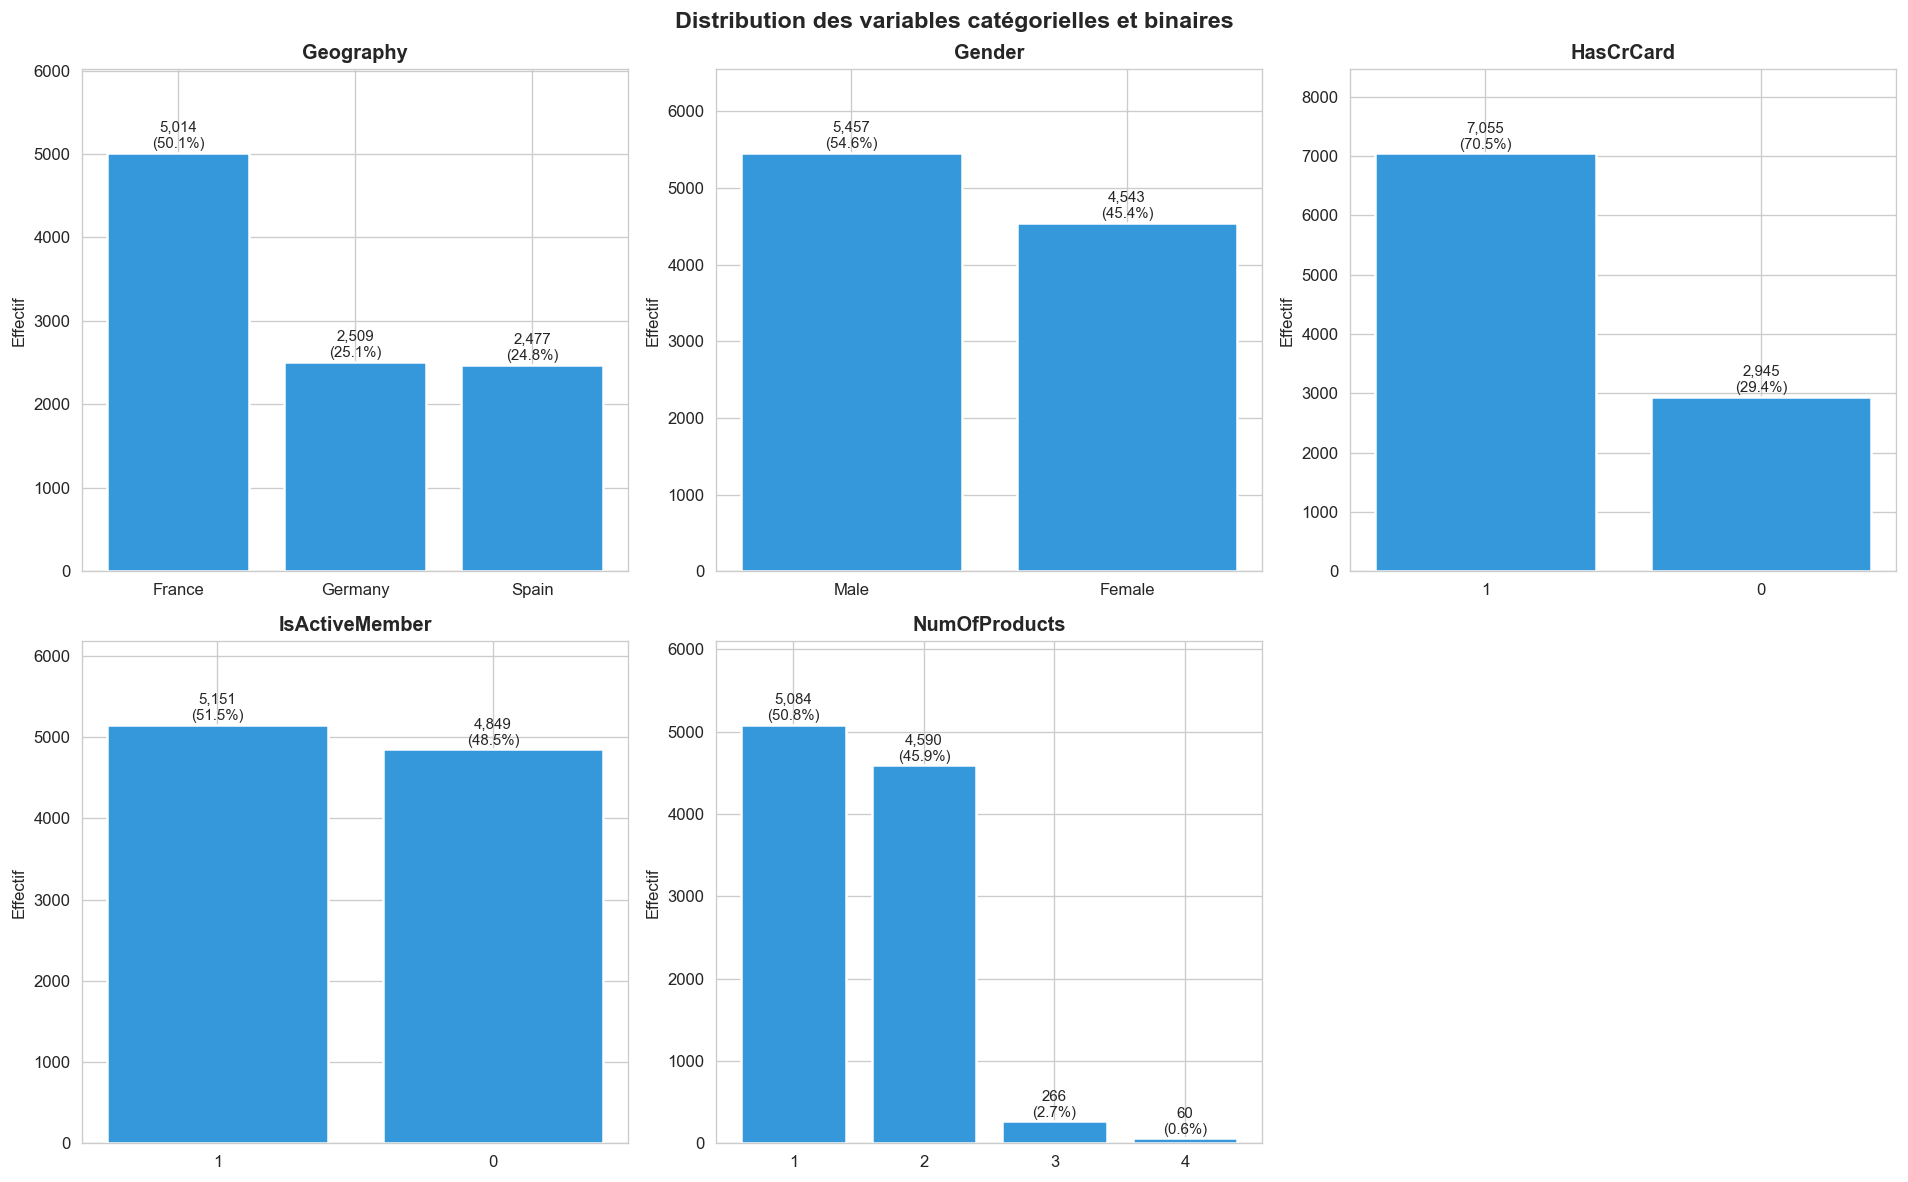

In [13]:
all_cat = cat_cols + bin_cols + ['NumOfProducts']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution des variables catégorielles et binaires', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(all_cat):
    ax = axes[i]
    vc = df_clean[col].value_counts()
    bars = ax.bar(vc.index.astype(str), vc.values, color='#3498db', edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{val:,}\n({val/len(df_clean)*100:.1f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Effectif')
    ax.set_ylim(0, vc.max() * 1.2)

for j in range(len(all_cat), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Analyse bivariée — Churn vs chaque feature

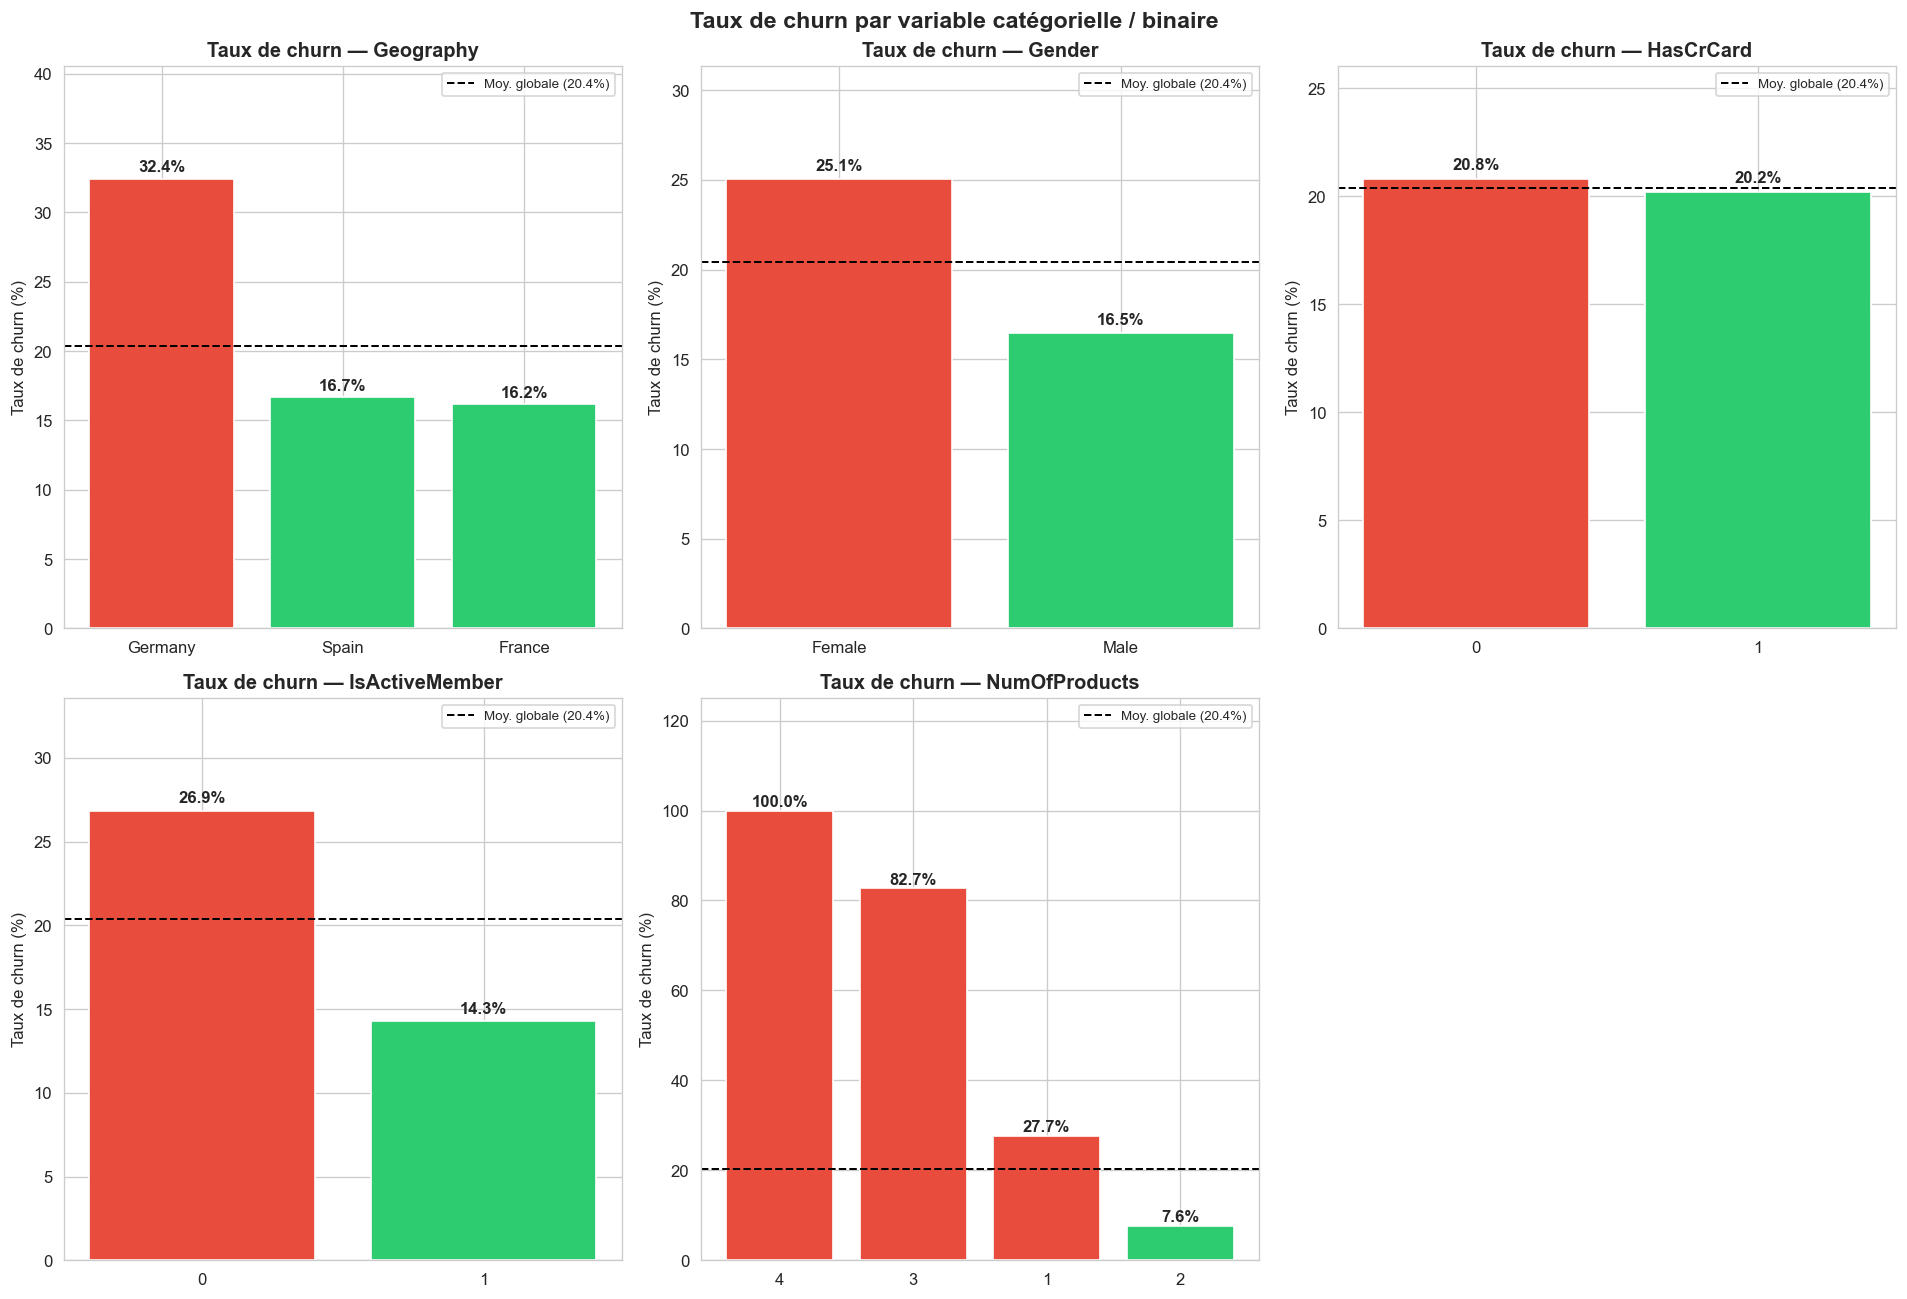

In [14]:
# Taux de churn par variable catégorielle / binaire / ordinale
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
fig.suptitle('Taux de churn par variable catégorielle / binaire', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(all_cat):
    ax = axes[i]
    churn_rate = df_clean.groupby(col)['Exited'].mean().sort_values(ascending=False) * 100
    colors = [COLOR_CHURN if v > 20.4 else COLOR_RETAIN for v in churn_rate.values]
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values, color=colors, edgecolor='white')
    ax.axhline(20.4, color='black', linestyle='--', linewidth=1.2, label='Moy. globale (20.4%)')
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set_title(f'Taux de churn — {col}', fontweight='bold')
    ax.set_ylabel('Taux de churn (%)')
    ax.set_ylim(0, churn_rate.max() * 1.25)
    ax.legend(fontsize=8)

for j in range(len(all_cat), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

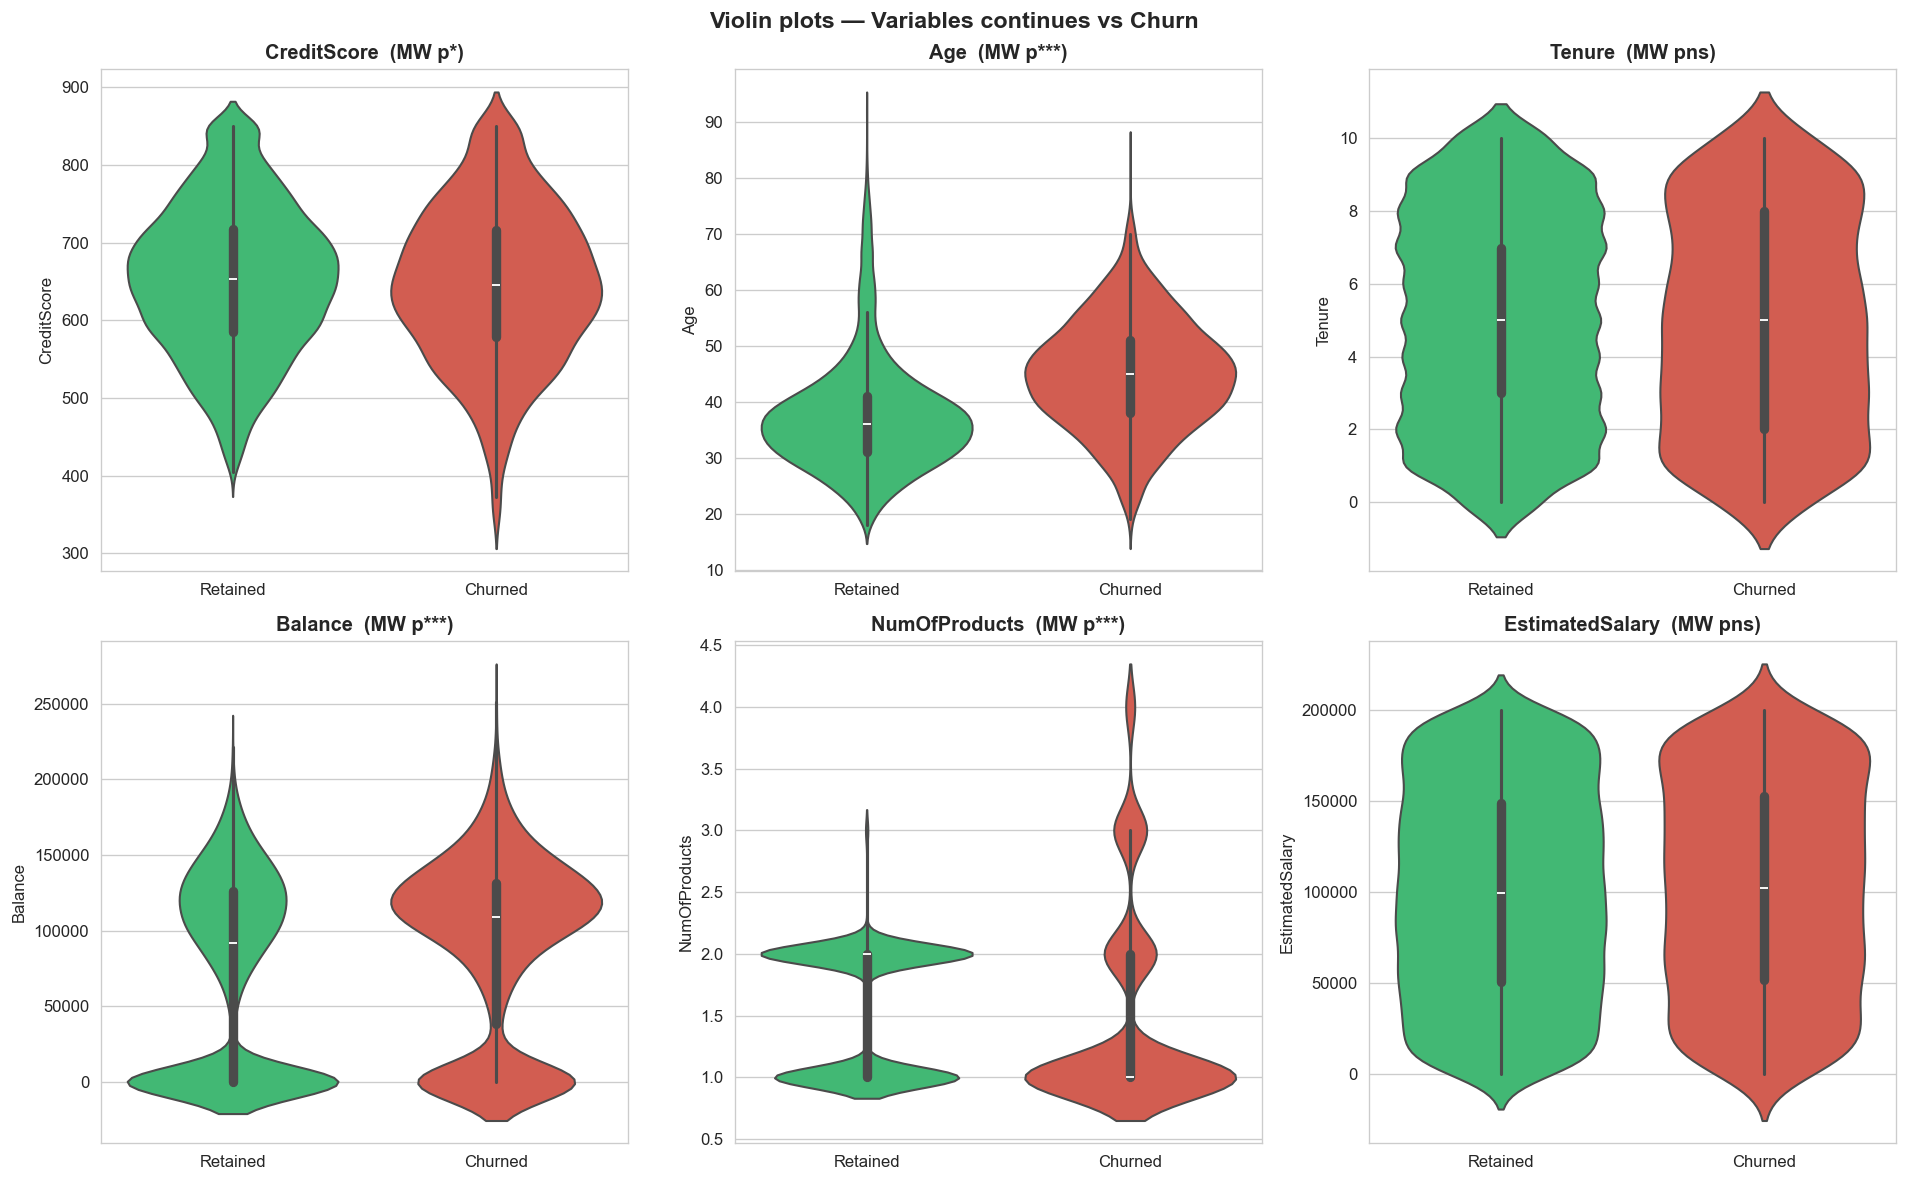

MW = Mann-Whitney U test  |  *** p<0.001  ** p<0.01  * p<0.05  ns = non significatif


In [15]:
# Violin plots : Age, CreditScore, Balance, EstimatedSalary vs Churn
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Violin plots — Variables continues vs Churn', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    ax = axes[i]
    data_plot = df_clean[[col, 'Exited']].copy()
    data_plot['Status'] = data_plot['Exited'].map({0: 'Retained', 1: 'Churned'})
    sns.violinplot(data=data_plot, x='Status', y=col, ax=ax,
                   palette={'Retained': COLOR_RETAIN, 'Churned': COLOR_CHURN},
                   order=['Retained', 'Churned'], inner='box')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    
    # Test de Mann-Whitney
    g0 = df_clean[df_clean['Exited']==0][col]
    g1 = df_clean[df_clean['Exited']==1][col]
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ax.set_title(f'{col}  (MW p{sig})', fontweight='bold')

for j in range(len(cont_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
print('MW = Mann-Whitney U test  |  *** p<0.001  ** p<0.01  * p<0.05  ns = non significatif')

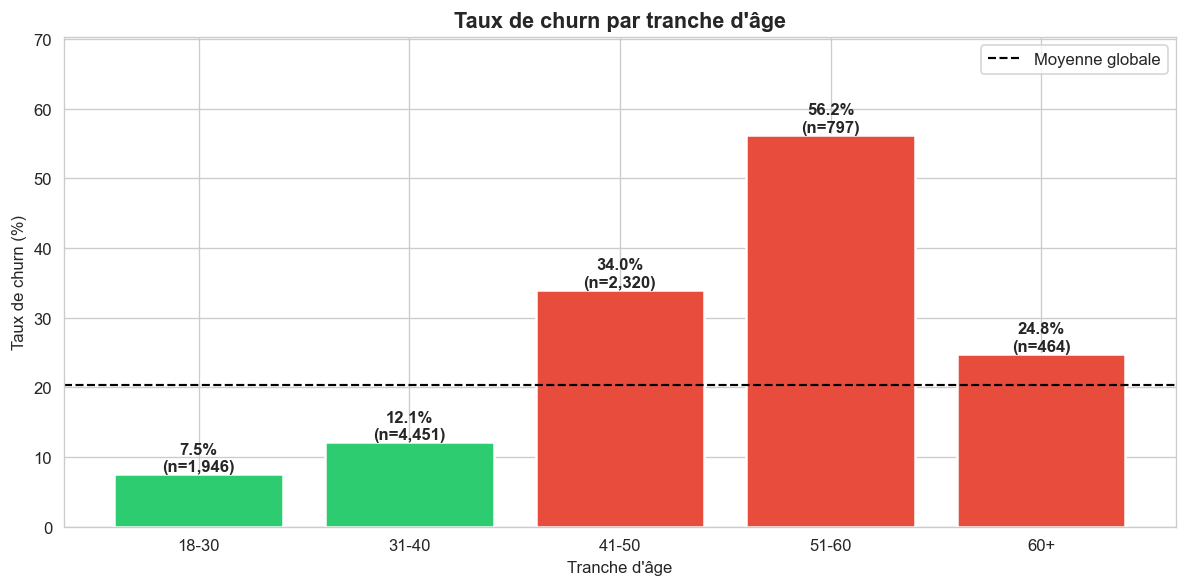

In [16]:
# Taux de churn par tranches d'âge
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=[18, 30, 40, 50, 60, 100],
                               labels=['18-30', '31-40', '41-50', '51-60', '60+'])

age_churn = df_clean.groupby('AgeGroup', observed=True)['Exited'].agg(['mean', 'count'])
age_churn['mean'] *= 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(age_churn.index.astype(str), age_churn['mean'],
              color=[COLOR_CHURN if v > 20.4 else COLOR_RETAIN for v in age_churn['mean']],
              edgecolor='white', linewidth=1.5)
ax.axhline(20.4, color='black', linestyle='--', linewidth=1.3, label='Moyenne globale')
for bar, (idx, row) in zip(bars, age_churn.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{row['mean']:.1f}%\n(n={int(row['count']):,})", ha='center', fontsize=10, fontweight='bold')
ax.set_title('Taux de churn par tranche d\'âge', fontsize=13, fontweight='bold')
ax.set_ylabel('Taux de churn (%)')
ax.set_xlabel('Tranche d\'âge')
ax.set_ylim(0, age_churn['mean'].max() * 1.25)
ax.legend()
plt.tight_layout()
plt.show()

df_clean.drop(columns=['AgeGroup'], inplace=True)

## 8. Matrice de corrélation

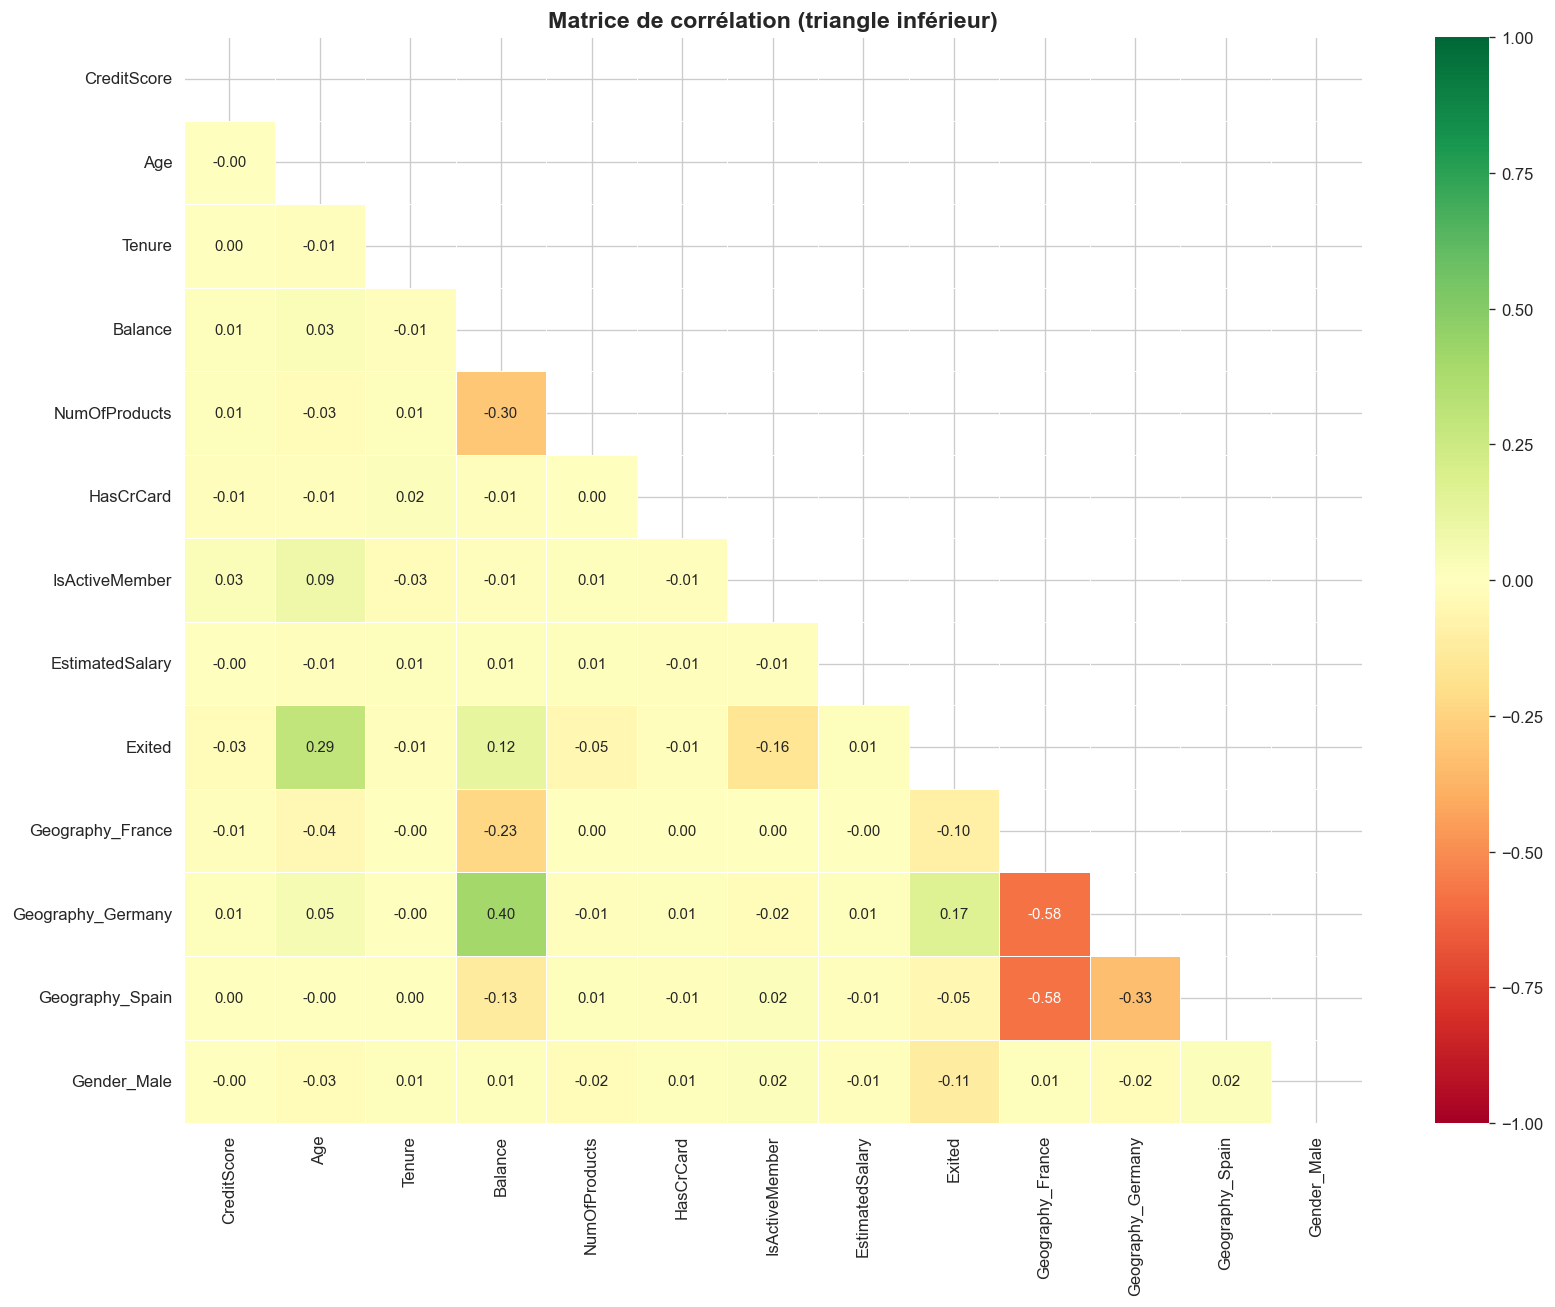


=== Corrélations avec Exited (triées) ===
Age                  0.29
Geography_Germany    0.17
IsActiveMember      -0.16
Balance              0.12
Gender_Male         -0.11
Geography_France    -0.10
NumOfProducts       -0.05
Geography_Spain     -0.05
CreditScore         -0.03
Tenure              -0.01
EstimatedSalary      0.01
HasCrCard           -0.01
Name: Exited, dtype: float64


In [17]:
# Encodage des variables catégorielles pour la corrélation
df_enc = df_clean.copy()
df_enc['Geography_France']  = (df_enc['Geography'] == 'France').astype(int)
df_enc['Geography_Germany'] = (df_enc['Geography'] == 'Germany').astype(int)
df_enc['Geography_Spain']   = (df_enc['Geography'] == 'Spain').astype(int)
df_enc['Gender_Male']       = (df_enc['Gender'] == 'Male').astype(int)
df_enc.drop(columns=['Geography', 'Gender'], inplace=True)

corr_matrix = df_enc.corr().round(2)

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Matrice de corrélation (triangle inférieur)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Corrélations avec Exited (triées) ===')
corr_target = corr_matrix['Exited'].drop('Exited').sort_values(key=abs, ascending=False)
print(corr_target)

## 9. Analyses croisées avancées

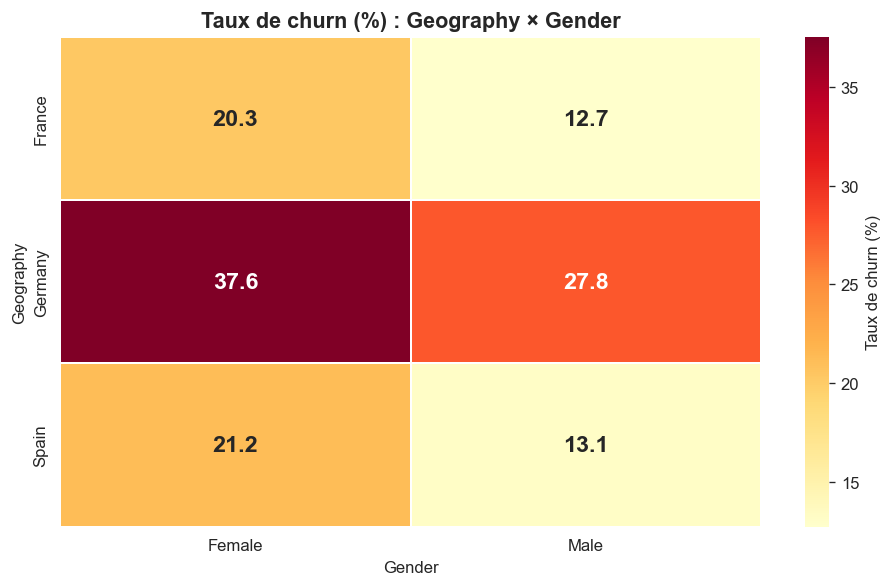

In [18]:
# Churn rate : Geography × Gender
pivot = df_clean.pivot_table(values='Exited', index='Geography', columns='Gender', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=1, annot_kws={'size': 14, 'weight': 'bold'},
            cbar_kws={'label': 'Taux de churn (%)'})
ax.set_title('Taux de churn (%) : Geography × Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

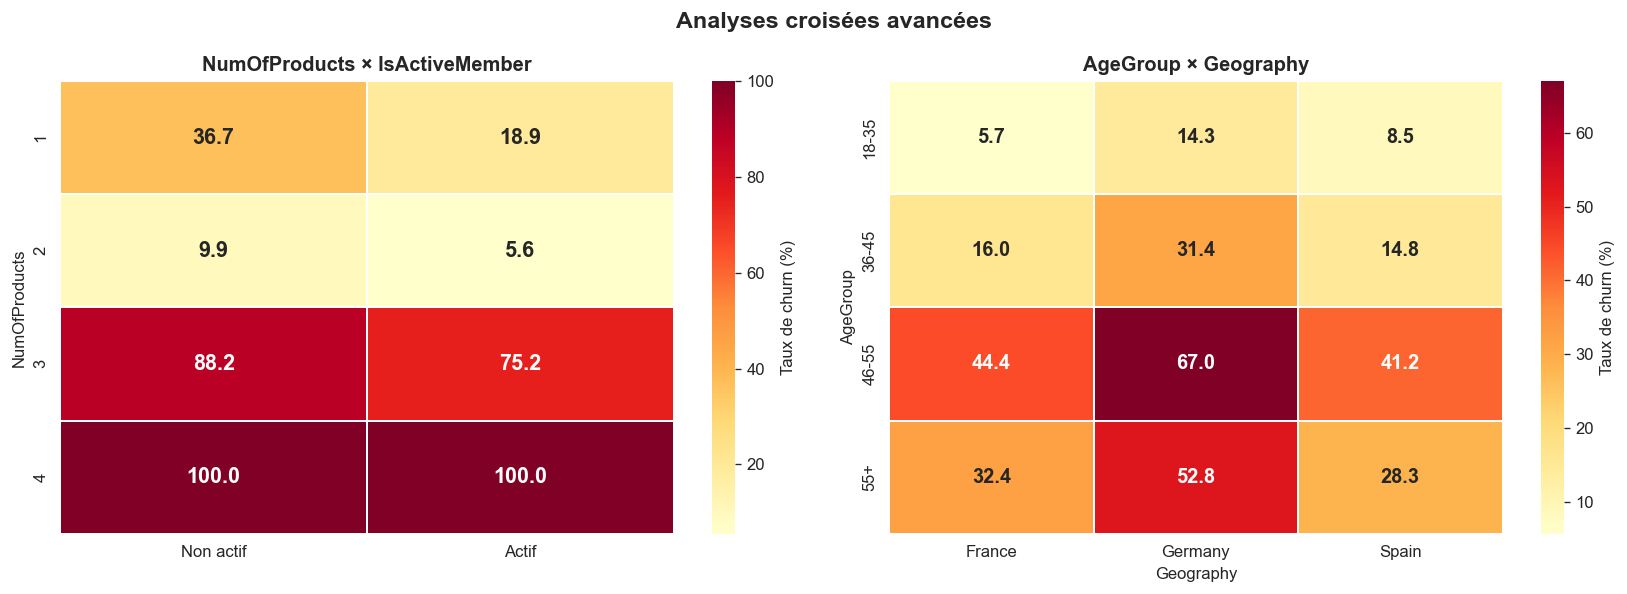

In [19]:
# Churn rate : NumOfProducts × IsActiveMember
pivot2 = df_clean.pivot_table(values='Exited', index='NumOfProducts',
                               columns='IsActiveMember', aggfunc='mean') * 100
pivot2.columns = ['Non actif', 'Actif']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analyses croisées avancées', fontsize=14, fontweight='bold')

sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0],
            linewidths=1, annot_kws={'size': 13, 'weight': 'bold'},
            cbar_kws={'label': 'Taux de churn (%)'})
axes[0].set_title('NumOfProducts × IsActiveMember', fontweight='bold')

# Churn rate : Age bins × Geography
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=[18, 35, 45, 55, 100],
                               labels=['18-35', '36-45', '46-55', '55+'])
pivot3 = df_clean.pivot_table(values='Exited', index='AgeGroup',
                               columns='Geography', aggfunc='mean', observed=True) * 100
sns.heatmap(pivot3, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            linewidths=1, annot_kws={'size': 12, 'weight': 'bold'},
            cbar_kws={'label': 'Taux de churn (%)'})
axes[1].set_title('AgeGroup × Geography', fontweight='bold')
df_clean.drop(columns=['AgeGroup'], inplace=True)

plt.tight_layout()
plt.show()

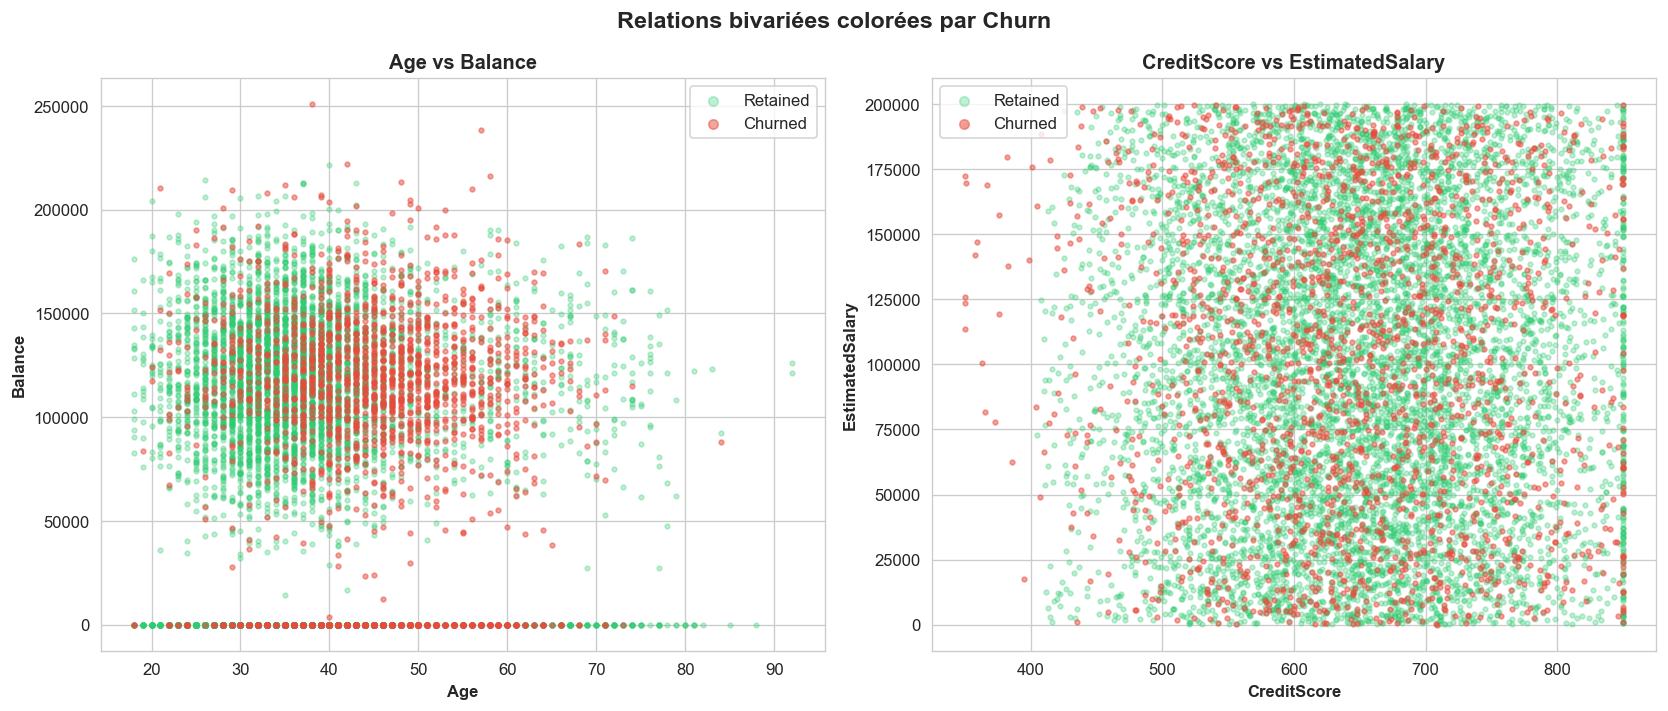

In [20]:
# Scatter plot Age vs Balance coloré par churn
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Relations bivariées colorées par Churn', fontsize=14, fontweight='bold')

colors = df_clean['Exited'].map({0: COLOR_RETAIN, 1: COLOR_CHURN})
for ax, x, y in zip(axes, ['Age', 'CreditScore'], ['Balance', 'EstimatedSalary']):
    ax.scatter(df_clean[df_clean['Exited']==0][x], df_clean[df_clean['Exited']==0][y],
               c=COLOR_RETAIN, alpha=0.3, s=8, label='Retained')
    ax.scatter(df_clean[df_clean['Exited']==1][x], df_clean[df_clean['Exited']==1][y],
               c=COLOR_CHURN, alpha=0.5, s=8, label='Churned')
    ax.set_xlabel(x, fontweight='bold')
    ax.set_ylabel(y, fontweight='bold')
    ax.set_title(f'{x} vs {y}', fontweight='bold')
    ax.legend(markerscale=2)

plt.tight_layout()
plt.show()

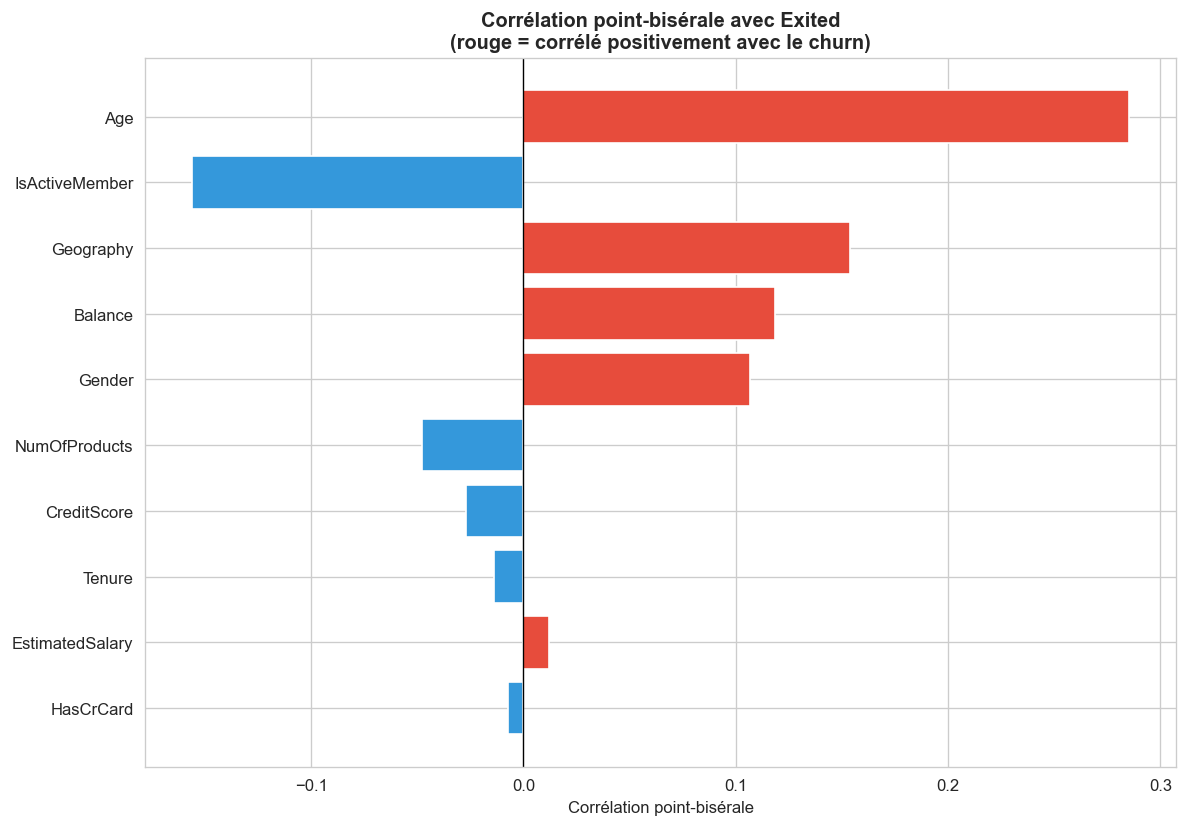

In [21]:
# Feature importance approximative via Point Biserial Correlation
from scipy.stats import pointbiserialr

df_enc2 = df_clean.copy()
df_enc2['Geography'] = df_enc2['Geography'].map({'France': 0, 'Spain': 1, 'Germany': 2})
df_enc2['Gender'] = df_enc2['Gender'].map({'Male': 0, 'Female': 1})

features = [c for c in df_enc2.columns if c != 'Exited']
correlations = {}
for feat in features:
    corr, p = pointbiserialr(df_enc2['Exited'], df_enc2[feat])
    correlations[feat] = {'corr': corr, 'abs_corr': abs(corr), 'p': p}

corr_df = pd.DataFrame(correlations).T.sort_values('abs_corr', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = [COLOR_CHURN if v > 0 else '#3498db' for v in corr_df['corr']]
ax.barh(corr_df.index, corr_df['corr'], color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Corrélation point-bisérale avec Exited\n(rouge = corrélé positivement avec le churn)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Corrélation point-bisérale')
plt.tight_layout()
plt.show()

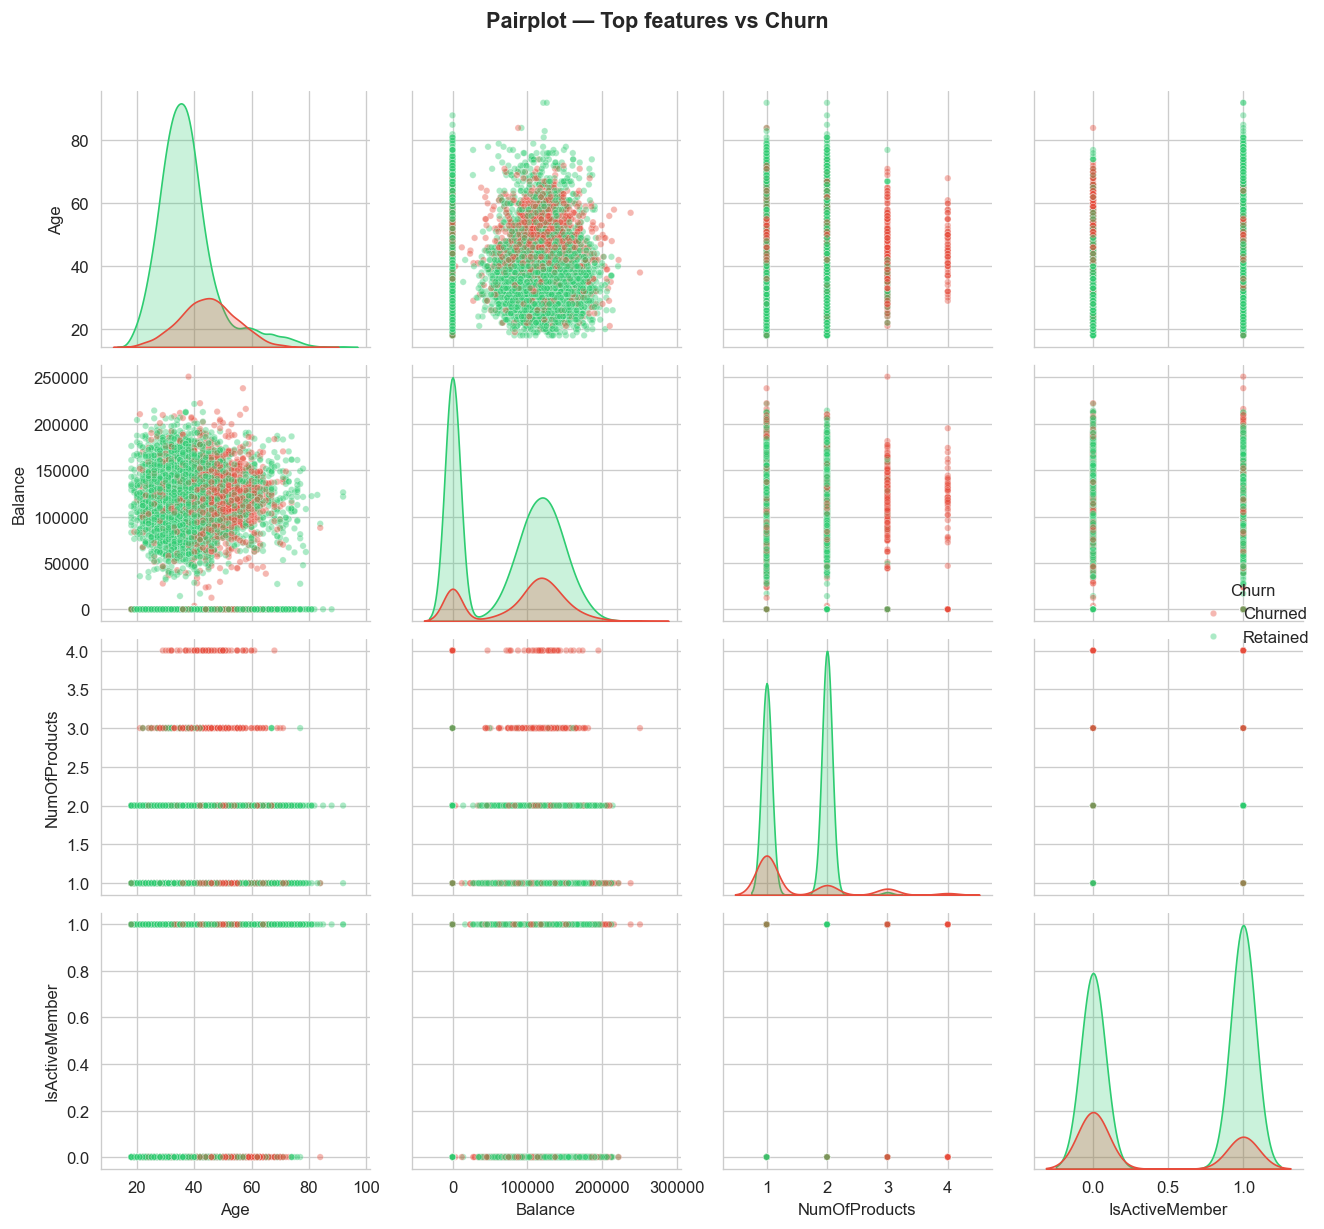

In [22]:
# Pairplot pour les variables les plus corrélées
top_features = ['Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Exited']
pair_df = df_clean[top_features].copy()
pair_df['Churn'] = pair_df['Exited'].map({0: 'Retained', 1: 'Churned'})

g = sns.pairplot(pair_df.drop(columns='Exited'), hue='Churn',
                 palette={'Retained': COLOR_RETAIN, 'Churned': COLOR_CHURN},
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kind='kde')
g.fig.suptitle('Pairplot — Top features vs Churn', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Synthèse & Conclusions

In [25]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║              SYNTHÈSE EDA — CHURN MODELLING                         ║
╚══════════════════════════════════════════════════════════════════════╝

📋 STRUCTURE DES DONNÉES
  • 10 000 clients, 14 colonnes, 0 valeur manquante, 0 doublon
  • Taux de churn : 20.4%  → dataset légèrement déséquilibré

🔑 FACTEURS LES PLUS LIÉS AU CHURN

  1. ÂGE (corrélation la plus forte ~+0.29)
     → Les clients 40-60 ans churnen beaucoup plus (~40-56%)
     → Les jeunes (< 35 ans) churnen peu (~10%)

  2. PAYS : Germany (corrélation ~+0.17)
     → Allemagne : ~32% de churn vs France/Espagne ~16%
     → Les femmes allemandes churnen le plus (~37%)

  3. NOMBRE DE PRODUITS (corrélation non-linéaire, critique)
     → 1 produit : ~27% de churn
     → 2 produits : ~7.6% de churn  (le meilleur profil)
     → 3-4 produits : >80% de churn  ⚠️ signal très fort

  4. MEMBRE ACTIF / INACTIF (corrélation ~-0.16)
     → Membres inactifs : ~27% vs actifs : ~14%

  5. GENRE : les femmes churnen plus (~25% vs ~16%)

  6. BALANCE
     → Les clients avec Balance = 0 churnen moins (~13%)
     → Distribution bimodale (0 ou ~100k+)

❌ VARIABLES PEU DISCRIMINANTES
  • CreditScore : quasi-identique entre les deux groupes
  • EstimatedSalary : aucune différence notable
  • HasCrCard : impact négligeable
  • Tenure : faible corrélation
""")


╔══════════════════════════════════════════════════════════════════════╗
║              SYNTHÈSE EDA — CHURN MODELLING                         ║
╚══════════════════════════════════════════════════════════════════════╝

📋 STRUCTURE DES DONNÉES
  • 10 000 clients, 14 colonnes, 0 valeur manquante, 0 doublon
  • Taux de churn : 20.4%  → dataset légèrement déséquilibré

🔑 FACTEURS LES PLUS LIÉS AU CHURN

  1. ÂGE (corrélation la plus forte ~+0.29)
     → Les clients 40-60 ans churnen beaucoup plus (~40-56%)
     → Les jeunes (< 35 ans) churnen peu (~10%)

  2. PAYS : Germany (corrélation ~+0.17)
     → Allemagne : ~32% de churn vs France/Espagne ~16%
     → Les femmes allemandes churnen le plus (~37%)

  3. NOMBRE DE PRODUITS (corrélation non-linéaire, critique)
     → 1 produit : ~27% de churn
     → 2 produits : ~7.6% de churn  (le meilleur profil)
     → 3-4 produits : >80% de churn  ⚠️ signal très fort

  4. MEMBRE ACTIF / INACTIF (corrélation ~-0.16)
     → Membres inactifs : ~27% vs 